In [2]:
# Imports and Load Cleaned Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("../../data/fraud/creditcard.csv")
df = df.drop_duplicates()

print("Cleaned dataset loaded")
print("Shape:", df.shape)
print("Fraud cases:", df["Class"].sum())

Cleaned dataset loaded
Shape: (283726, 31)
Fraud cases: 473


ENGINEERING TIME-BASED FEATURES

Features created:
  hour_of_day         : hour extracted from Time column (0-23)
  day_number          : which day of dataset (1 or 2)
  is_night            : 1 if transaction between 10PM and 5AM
  is_peak_fraud_hour  : 1 if transaction between 1AM and 3AM
  time_bin            : categorical time of day

Fraud rate during night hours  : 0.2759%
Fraud rate during day hours    : 0.1450%
Fraud rate during peak hours   : 0.7716%
Overall fraud rate             : 0.1667%

Fraud rate by time bin:
           total_transactions  fraud_count  fraud_rate_%
time_bin                                                
night                   23843          115        0.4823
morning                 70648          118        0.1670
afternoon               96119          133        0.1384
evening                 93116          107        0.1149


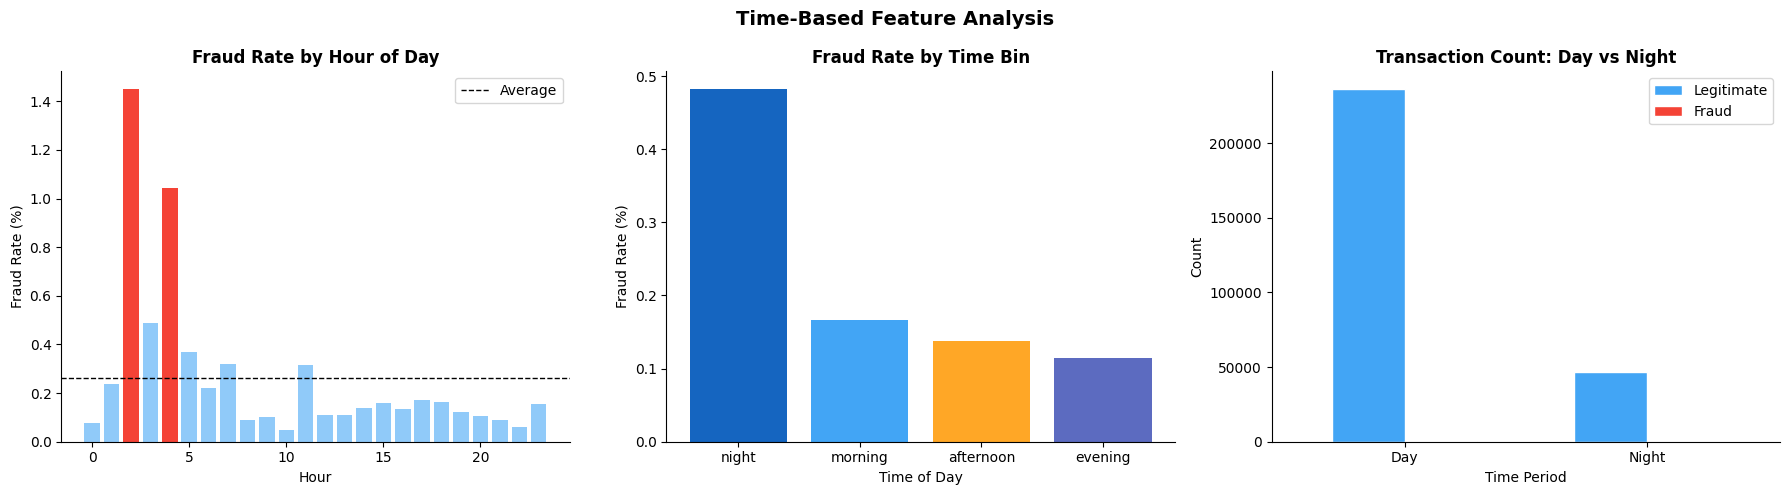

In [4]:
#  Time Based Features
print("ENGINEERING TIME-BASED FEATURES")
print()

df["hour_of_day"] = (df["Time"] / 3600) % 24
df["day_number"] = (df["Time"] / 3600 / 24).astype(int) + 1
df["is_night"] = ((df["hour_of_day"] >= 22) | (df["hour_of_day"] <= 5)).astype(int)
df["is_peak_fraud_hour"] = ((df["hour_of_day"] >= 1) & (df["hour_of_day"] <= 3)).astype(int)
df["time_bin"] = pd.cut(df["hour_of_day"],
                         bins=[0, 6, 12, 18, 24],
                         labels=["night", "morning", "afternoon", "evening"],
                         include_lowest=True)

print("Features created:")
print("  hour_of_day         : hour extracted from Time column (0-23)")
print("  day_number          : which day of dataset (1 or 2)")
print("  is_night            : 1 if transaction between 10PM and 5AM")
print("  is_peak_fraud_hour  : 1 if transaction between 1AM and 3AM")
print("  time_bin            : categorical time of day")
print()

night_fraud = df[df["is_night"] == 1]["Class"].mean() * 100
day_fraud = df[df["is_night"] == 0]["Class"].mean() * 100
peak_fraud = df[df["is_peak_fraud_hour"] == 1]["Class"].mean() * 100

print(f"Fraud rate during night hours  : {night_fraud:.4f}%")
print(f"Fraud rate during day hours    : {day_fraud:.4f}%")
print(f"Fraud rate during peak hours   : {peak_fraud:.4f}%")
print(f"Overall fraud rate             : {df['Class'].mean()*100:.4f}%")
print()

time_bin_fraud = df.groupby("time_bin", observed=True)["Class"].agg(["mean", "count", "sum"])
time_bin_fraud["fraud_rate_%"] = time_bin_fraud["mean"] * 100
time_bin_fraud = time_bin_fraud.drop(columns="mean")
time_bin_fraud.columns = ["total_transactions", "fraud_count", "fraud_rate_%"]
print("Fraud rate by time bin:")
print(time_bin_fraud)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fraud_by_hour = df.groupby(df["hour_of_day"].astype(int))["Class"].mean() * 100
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color=[
    "#F44336" if v > fraud_by_hour.mean() * 2 else "#90CAF9" for v in fraud_by_hour.values])
axes[0].set_title("Fraud Rate by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].axhline(fraud_by_hour.mean(), color="black", linestyle="--", linewidth=1, label="Average")
axes[0].legend()

time_bin_plot = df.groupby("time_bin", observed=True)["Class"].mean() * 100
axes[1].bar(time_bin_plot.index, time_bin_plot.values,
            color=["#1565C0", "#42A5F5", "#FFA726", "#5C6BC0"])
axes[1].set_title("Fraud Rate by Time Bin", fontweight="bold")
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("Fraud Rate (%)")

night_counts = df.groupby(["is_night", "Class"]).size().unstack()
night_counts.index = ["Day", "Night"]
night_counts.plot(kind="bar", ax=axes[2], color=["#42A5F5", "#F44336"],
                  edgecolor="white", width=0.6)
axes[2].set_title("Transaction Count: Day vs Night", fontweight="bold")
axes[2].set_xlabel("Time Period")
axes[2].set_ylabel("Count")
axes[2].set_xticklabels(["Day", "Night"], rotation=0)
axes[2].legend(["Legitimate", "Fraud"])

plt.suptitle("Time-Based Feature Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/time_features.png", dpi=150, bbox_inches="tight")
plt.show()

ENGINEERING AMOUNT-BASED FEATURES

Features created:
  amount_log        : log(1 + Amount) to reduce skewness
  is_zero_amount    : 1 if transaction amount is zero
  is_small_amount   : 1 if amount less than $10
  is_round_amount   : 1 if amount is a round number
  amount_above_99p  : 1 if amount exceeds 99th percentile
  amount_quartile   : which quartile the amount falls in

Fraud rates for amount-based features:
  is_zero_amount        : 1.3827% fraud rate  (lift: 8.29x vs overall)
  is_small_amount       : 0.2457% fraud rate  (lift: 1.47x vs overall)
  is_round_amount       : 0.2309% fraud rate  (lift: 1.39x vs overall)
  amount_above_99p      : 0.3171% fraud rate  (lift: 1.90x vs overall)

Fraud rate by amount quartile:
                 total  fraud_count  fraud_rate_%
amount_quartile                                  
Q1               70940          213        0.3003
Q2               71035           47        0.0662
Q3               70820           45        0.0635
Q4             

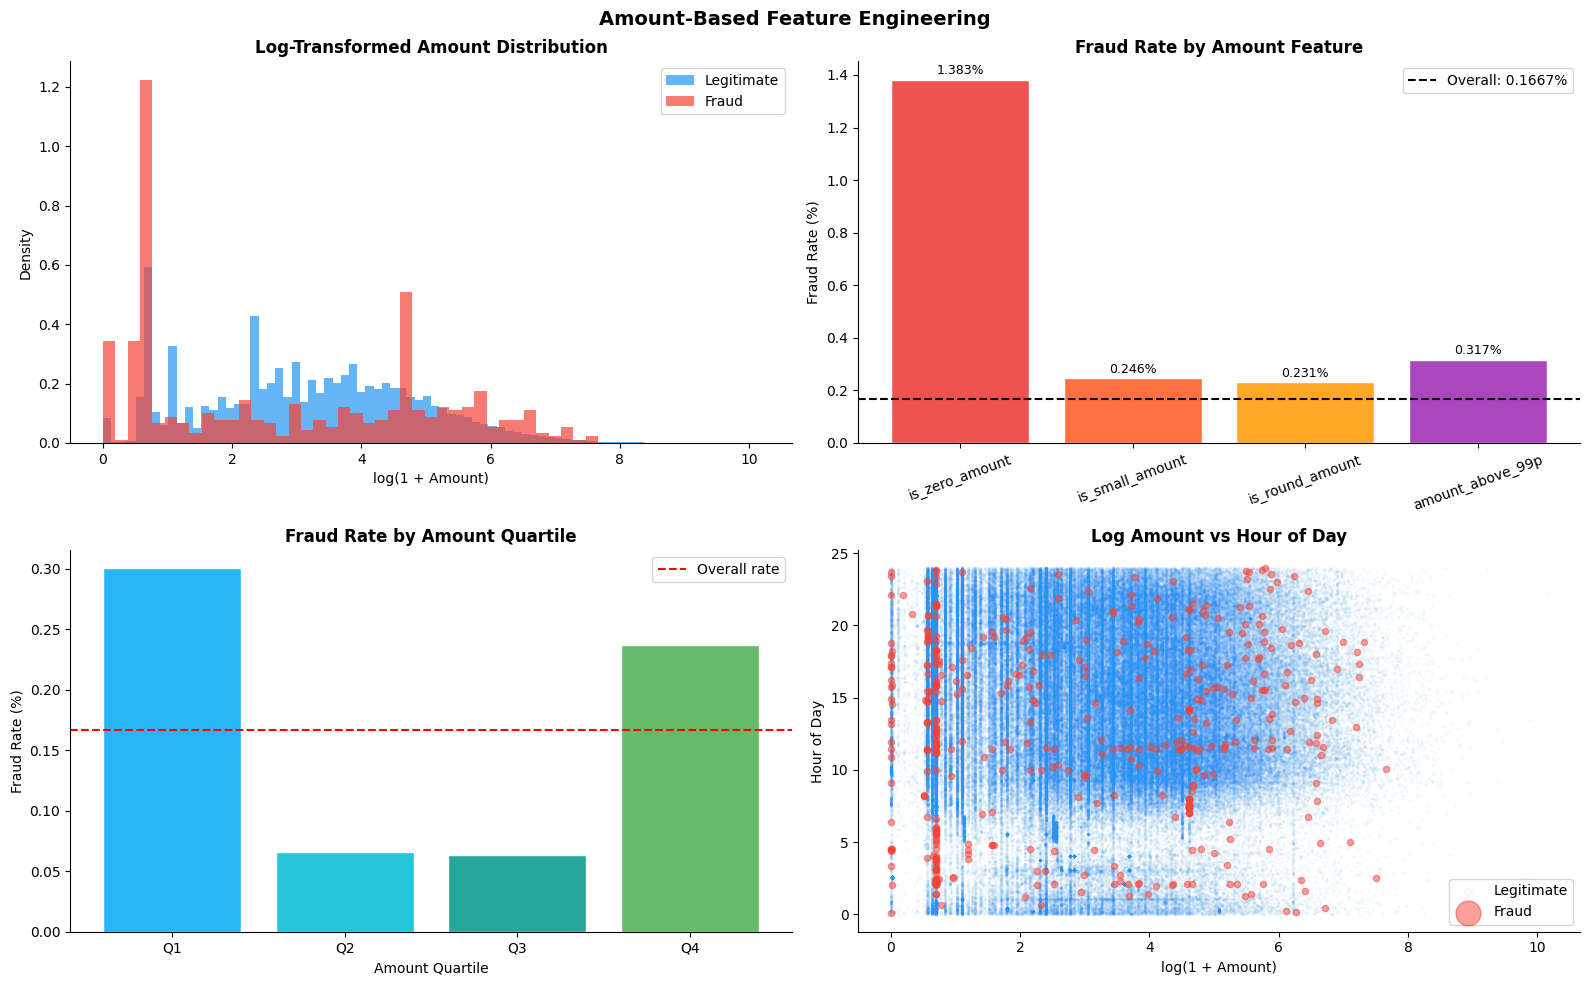

In [5]:
# Amount Based Features
print("ENGINEERING AMOUNT-BASED FEATURES")
print()

df["amount_log"] = np.log1p(df["Amount"])
df["is_zero_amount"] = (df["Amount"] == 0).astype(int)
df["is_small_amount"] = (df["Amount"] < 10).astype(int)
df["is_round_amount"] = (df["Amount"] % 1 == 0).astype(int)
df["amount_above_99p"] = (df["Amount"] > df["Amount"].quantile(0.99)).astype(int)

amount_percentiles = df["Amount"].quantile([0.25, 0.5, 0.75, 0.90, 0.95])
df["amount_quartile"] = pd.qcut(df["Amount"].clip(upper=df["Amount"].quantile(0.99)),
                                  q=4, labels=["Q1", "Q2", "Q3", "Q4"])

print("Features created:")
print("  amount_log        : log(1 + Amount) to reduce skewness")
print("  is_zero_amount    : 1 if transaction amount is zero")
print("  is_small_amount   : 1 if amount less than $10")
print("  is_round_amount   : 1 if amount is a round number")
print("  amount_above_99p  : 1 if amount exceeds 99th percentile")
print("  amount_quartile   : which quartile the amount falls in")
print()

print("Fraud rates for amount-based features:")
for feature in ["is_zero_amount", "is_small_amount", "is_round_amount", "amount_above_99p"]:
    overall = df["Class"].mean() * 100
    feature_fraud = df[df[feature] == 1]["Class"].mean() * 100
    lift = feature_fraud / overall
    print(f"  {feature:<22}: {feature_fraud:.4f}% fraud rate  (lift: {lift:.2f}x vs overall)")

print()
print("Fraud rate by amount quartile:")
quartile_fraud = df.groupby("amount_quartile", observed=True)["Class"].agg(["mean", "count", "sum"])
quartile_fraud["fraud_rate_%"] = quartile_fraud["mean"] * 100
print(quartile_fraud[["count", "sum", "fraud_rate_%"]].rename(
    columns={"count": "total", "sum": "fraud_count"}))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(df[df["Class"] == 0]["amount_log"], bins=80,
                color="#2196F3", alpha=0.7, label="Legitimate", density=True)
axes[0, 0].hist(df[df["Class"] == 1]["amount_log"], bins=40,
                color="#F44336", alpha=0.7, label="Fraud", density=True)
axes[0, 0].set_title("Log-Transformed Amount Distribution", fontweight="bold")
axes[0, 0].set_xlabel("log(1 + Amount)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

binary_features = ["is_zero_amount", "is_small_amount", "is_round_amount", "amount_above_99p"]
fraud_rates = [df[df[f] == 1]["Class"].mean() * 100 for f in binary_features]
overall_rate = df["Class"].mean() * 100
bars = axes[0, 1].bar(binary_features, fraud_rates,
                       color=["#EF5350", "#FF7043", "#FFA726", "#AB47BC"], edgecolor="white")
axes[0, 1].axhline(overall_rate, color="black", linestyle="--",
                    linewidth=1.5, label=f"Overall: {overall_rate:.4f}%")
axes[0, 1].set_title("Fraud Rate by Amount Feature", fontweight="bold")
axes[0, 1].set_ylabel("Fraud Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].legend()
for bar, val in zip(bars, fraud_rates):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.01, f"{val:.3f}%",
                     ha="center", va="bottom", fontsize=9)

quartile_rates = df.groupby("amount_quartile", observed=True)["Class"].mean() * 100
axes[1, 0].bar(quartile_rates.index, quartile_rates.values,
               color=["#29B6F6", "#26C6DA", "#26A69A", "#66BB6A"], edgecolor="white")
axes[1, 0].set_title("Fraud Rate by Amount Quartile", fontweight="bold")
axes[1, 0].set_xlabel("Amount Quartile")
axes[1, 0].set_ylabel("Fraud Rate (%)")
axes[1, 0].axhline(overall_rate, color="red", linestyle="--", linewidth=1.5, label="Overall rate")
axes[1, 0].legend()

axes[1, 1].scatter(df[df["Class"] == 0]["amount_log"],
                    df[df["Class"] == 0]["hour_of_day"],
                    alpha=0.03, color="#2196F3", s=2, label="Legitimate")
axes[1, 1].scatter(df[df["Class"] == 1]["amount_log"],
                    df[df["Class"] == 1]["hour_of_day"],
                    alpha=0.5, color="#F44336", s=20, label="Fraud")
axes[1, 1].set_title("Log Amount vs Hour of Day", fontweight="bold")
axes[1, 1].set_xlabel("log(1 + Amount)")
axes[1, 1].set_ylabel("Hour of Day")
axes[1, 1].legend(markerscale=4)

plt.suptitle("Amount-Based Feature Engineering", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/amount_features.png", dpi=150, bbox_inches="tight")
plt.show()

ENGINEERING PCA INTERACTION FEATURES

Features created:
  V14_V3_interaction    : product of two most discriminative features
  V17_V12_interaction   : product of next two most discriminative features
  V14_abs, V3_abs, ...  : absolute values of top discriminative features
  top_features_sum_abs  : sum of absolute values of top 7 features
  top_features_max_abs  : max absolute value among top 7 features
  V14_V17_euclidean     : euclidean distance in V14-V17 space

Discriminative power of new interaction features:
(measured by absolute mean difference between fraud and legitimate)
  V14_V3_interaction            : separation = 59.6071  (fraud mean=59.5034, legit mean=-0.1037)
  V17_V12_interaction           : separation = 66.2474  (fraud mean=66.1262, legit mean=-0.1212)
  V14_abs                       : separation = 6.2802  (fraud mean=6.9167, legit mean=0.6365)
  top_features_sum_abs          : separation = 35.5707  (fraud mean=41.1394, legit mean=5.5687)
  top_features_max_abs      

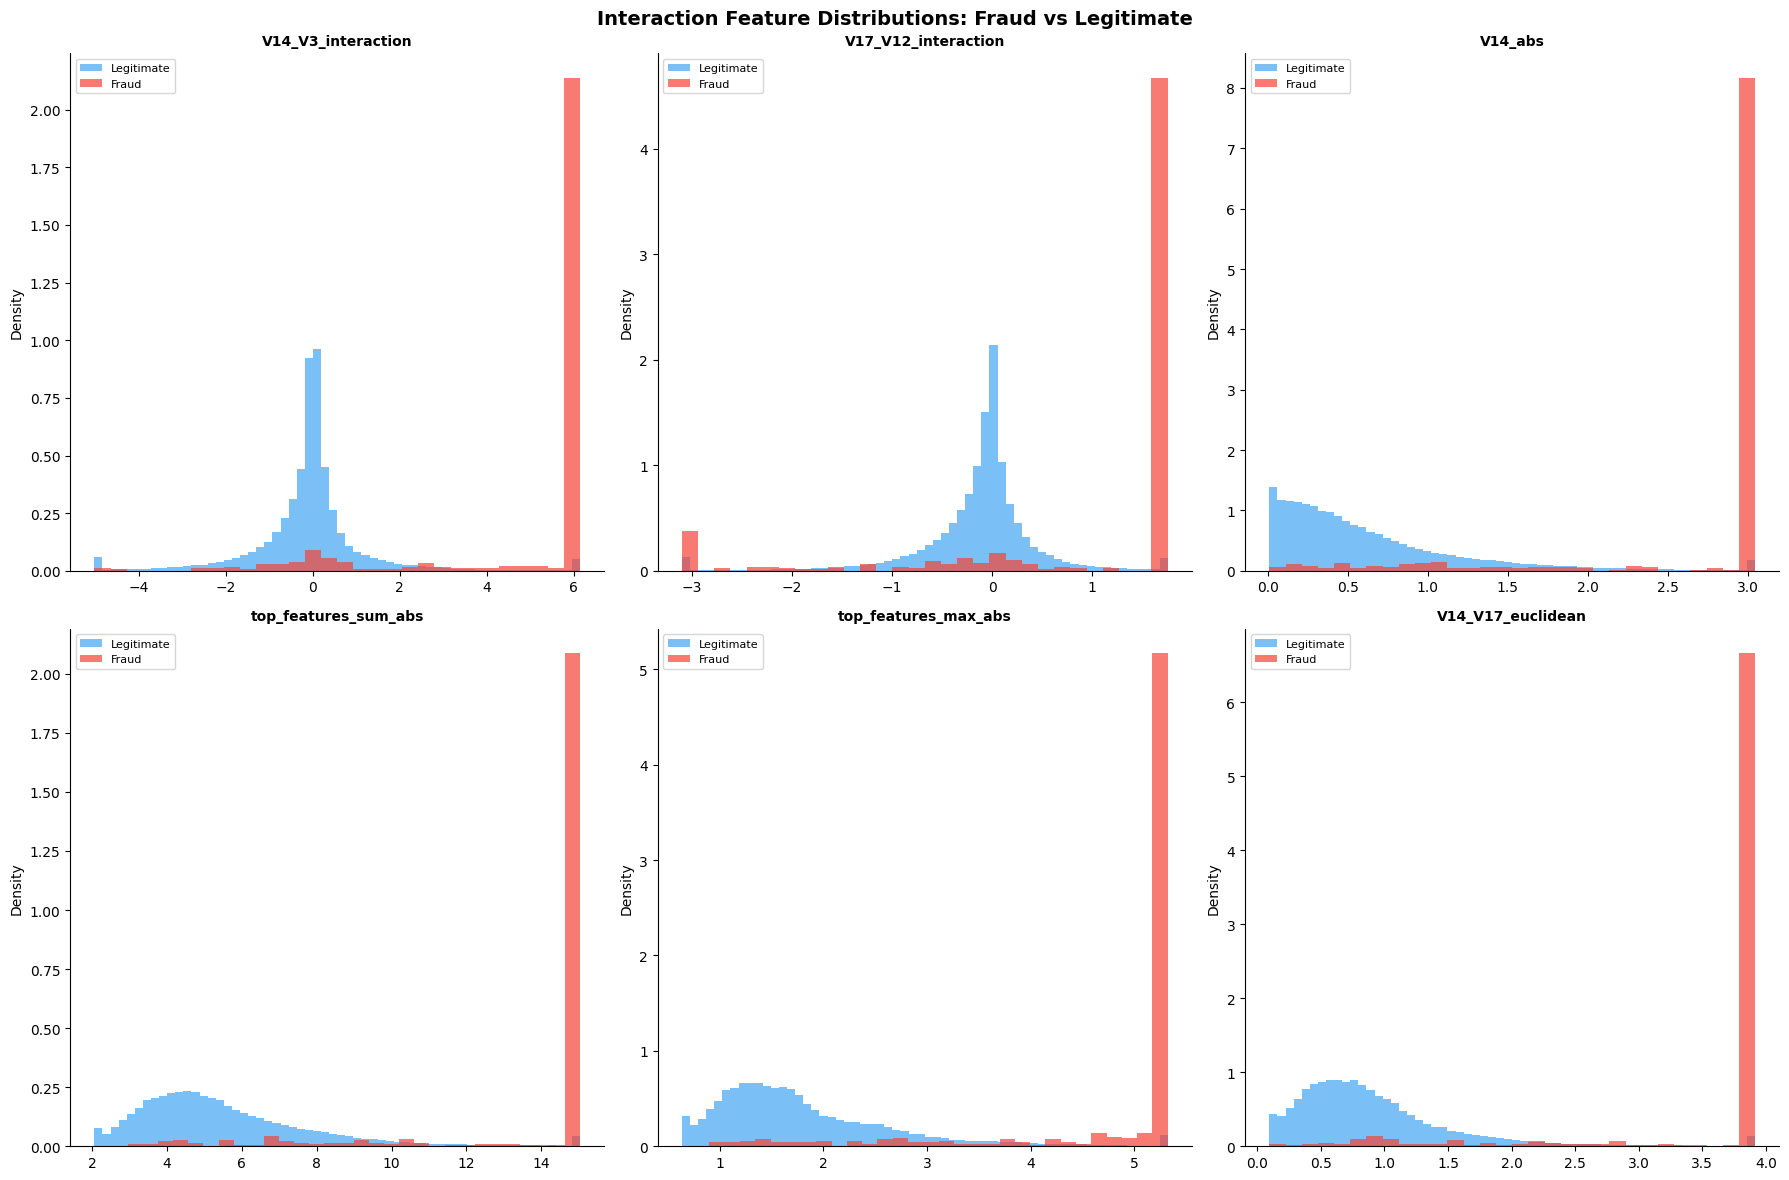

In [6]:
# PCA Feature Interaction Features
print("ENGINEERING PCA INTERACTION FEATURES")
print()

top_features = ["V14", "V3", "V17", "V12", "V10", "V11", "V4"]

df["V14_V3_interaction"] = df["V14"] * df["V3"]
df["V17_V12_interaction"] = df["V17"] * df["V12"]
df["V14_abs"] = df["V14"].abs()
df["V3_abs"] = df["V3"].abs()
df["V17_abs"] = df["V17"].abs()
df["V12_abs"] = df["V12"].abs()
df["V10_abs"] = df["V10"].abs()
df["V11_abs"] = df["V11"].abs()
df["top_features_sum_abs"] = df[top_features].abs().sum(axis=1)
df["top_features_max_abs"] = df[top_features].abs().max(axis=1)
df["V14_V17_euclidean"] = np.sqrt(df["V14"] ** 2 + df["V17"] ** 2)

print("Features created:")
print("  V14_V3_interaction    : product of two most discriminative features")
print("  V17_V12_interaction   : product of next two most discriminative features")
print("  V14_abs, V3_abs, ...  : absolute values of top discriminative features")
print("  top_features_sum_abs  : sum of absolute values of top 7 features")
print("  top_features_max_abs  : max absolute value among top 7 features")
print("  V14_V17_euclidean     : euclidean distance in V14-V17 space")
print()

new_features = ["V14_V3_interaction", "V17_V12_interaction", "V14_abs",
                "top_features_sum_abs", "top_features_max_abs", "V14_V17_euclidean"]

print("Discriminative power of new interaction features:")
print("(measured by absolute mean difference between fraud and legitimate)")
for feat in new_features:
    fraud_mean = df[df["Class"] == 1][feat].mean()
    legit_mean = df[df["Class"] == 0][feat].mean()
    separation = abs(fraud_mean - legit_mean)
    print(f"  {feat:<30}: separation = {separation:.4f}  "
          f"(fraud mean={fraud_mean:.4f}, legit mean={legit_mean:.4f})")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    legit_vals = df[df["Class"] == 0][feat].clip(
        df[feat].quantile(0.01), df[feat].quantile(0.99))
    fraud_vals = df[df["Class"] == 1][feat].clip(
        df[feat].quantile(0.01), df[feat].quantile(0.99))
    axes[i].hist(legit_vals, bins=60, color="#2196F3", alpha=0.6,
                  label="Legitimate", density=True)
    axes[i].hist(fraud_vals, bins=30, color="#F44336", alpha=0.7,
                  label="Fraud", density=True)
    axes[i].set_title(f"{feat}", fontweight="bold", fontsize=10)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

plt.suptitle("Interaction Feature Distributions: Fraud vs Legitimate",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/interaction_features.png", dpi=150, bbox_inches="tight")
plt.show()

ENGINEERING VELOCITY AND BEHAVIORAL FEATURES

Note: True velocity requires user ID which is anonymized in this dataset.
We approximate velocity using time windows on the sorted transaction stream.

Velocity features created:
  txn_count_10s  : avg fraud=17.29, avg legit=20.92
  txn_count_30s  : avg fraud=51.74, avg legit=62.27
  txn_count_60s  : avg fraud=103.36, avg legit=123.78
  txn_count_300s  : avg fraud=514.82, avg legit=611.20

Merging velocity features back to main dataframe...
Done.



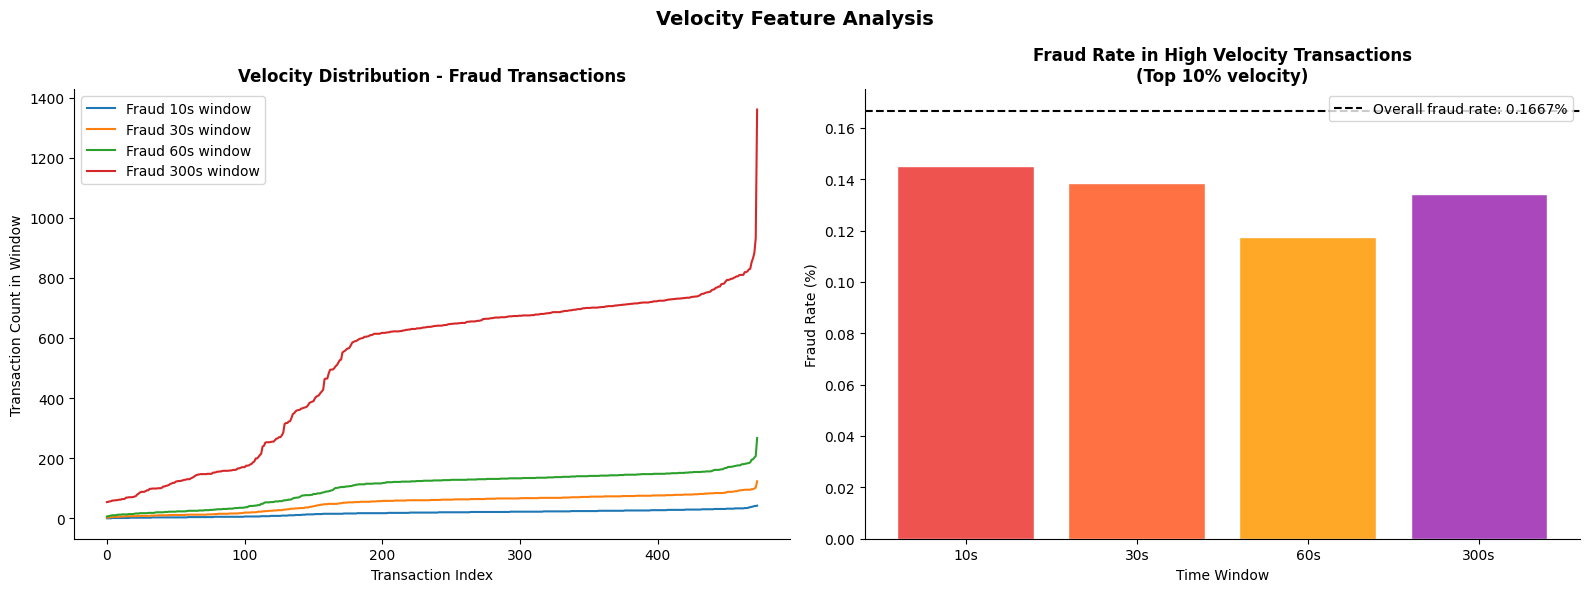

In [8]:
# Velocity and Behavioral Features
print("ENGINEERING VELOCITY AND BEHAVIORAL FEATURES")
print()
print("Note: True velocity requires user ID which is anonymized in this dataset.")
print("We approximate velocity using time windows on the sorted transaction stream.")
print()

df_sorted = df.sort_values("Time").reset_index(drop=True)

window_sizes = [10, 30, 60, 300]

for window in window_sizes:
    col_name = f"txn_count_{window}s"
    amount_col = f"amount_sum_{window}s"
    counts = []
    amounts = []
    for idx, row in df_sorted.iterrows():
        window_df = df_sorted[
            (df_sorted["Time"] >= row["Time"] - window) &
            (df_sorted["Time"] < row["Time"])
        ]
        counts.append(len(window_df))
        amounts.append(window_df["Amount"].sum())
    df_sorted[col_name] = counts
    df_sorted[amount_col] = amounts

print("Velocity features created:")
for window in window_sizes:
    fraud_velocity = df_sorted[df_sorted["Class"] == 1][f"txn_count_{window}s"].mean()
    legit_velocity = df_sorted[df_sorted["Class"] == 0][f"txn_count_{window}s"].mean()
    print(f"  txn_count_{window}s  : avg fraud={fraud_velocity:.2f}, avg legit={legit_velocity:.2f}")

print()
print("Merging velocity features back to main dataframe...")
velocity_cols = [f"txn_count_{w}s" for w in window_sizes] + [f"amount_sum_{w}s" for w in window_sizes]
df = df.merge(df_sorted[["Time", "Amount"] + velocity_cols].drop_duplicates(),
              on=["Time", "Amount"], how="left")
print("Done.")
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for window in window_sizes:
    col = f"txn_count_{window}s"
    fraud_vals = df_sorted[df_sorted["Class"] == 1][col]
    legit_vals = df_sorted[df_sorted["Class"] == 0][col]
    axes[0].plot(sorted(fraud_vals), label=f"Fraud {window}s window")

axes[0].set_title("Velocity Distribution - Fraud Transactions", fontweight="bold")
axes[0].set_xlabel("Transaction Index")
axes[0].set_ylabel("Transaction Count in Window")
axes[0].legend()

velocity_fraud_rates = []
for window in window_sizes:
    col = f"txn_count_{window}s"
    high_velocity = df[df[col] > df[col].quantile(0.90)]
    velocity_fraud_rates.append(high_velocity["Class"].mean() * 100)

axes[1].bar([f"{w}s" for w in window_sizes], velocity_fraud_rates,
            color=["#EF5350", "#FF7043", "#FFA726", "#AB47BC"], edgecolor="white")
axes[1].axhline(df["Class"].mean() * 100, color="black", linestyle="--",
                 linewidth=1.5, label=f"Overall fraud rate: {df['Class'].mean()*100:.4f}%")
axes[1].set_title("Fraud Rate in High Velocity Transactions\n(Top 10% velocity)", fontweight="bold")
axes[1].set_xlabel("Time Window")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].legend()

plt.suptitle("Velocity Feature Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/velocity_features.png", dpi=150, bbox_inches="tight")
plt.show()

FEATURE IMPORTANCE RANKING

Top 20 most important features (Random Forest):
   1. V14_V17_euclidean              0.116978  ##########################################################
   2. top_features_sum_abs           0.095479  ###############################################
   3. V14                            0.089648  ############################################
   4. top_features_max_abs           0.078693  #######################################
   5. V17_abs                        0.069685  ##################################
   6. V10                            0.061937  ##############################
   7. V14_abs                        0.054225  ###########################
   8. V14_V3_interaction             0.047681  #######################
   9. V12                            0.040373  ####################
  10. V17_V12_interaction            0.037827  ##################
  11. V12_abs                        0.031797  ###############
  12. V4                             0.02

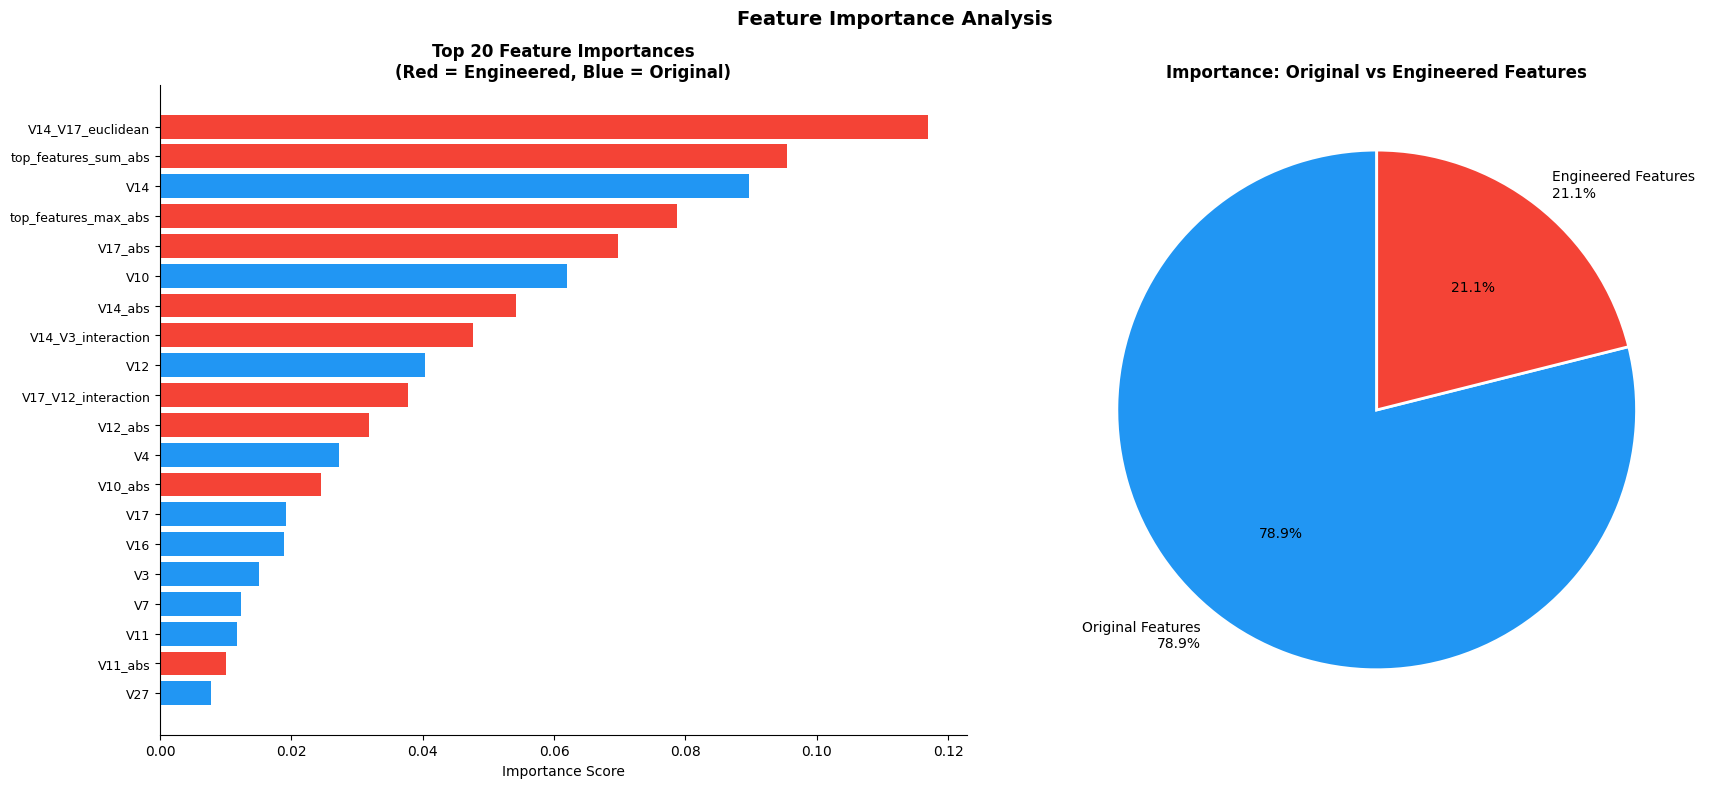


Engineered features total importance contribution: 21.08 %
Original features total importance contribution : 78.92 %


In [9]:
#  Feature Importance Ranking
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

print("FEATURE IMPORTANCE RANKING")
print()

encode_cols = ["time_bin", "amount_quartile"]
le = LabelEncoder()
df_model = df.copy()
for col in encode_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

drop_cols = ["Class", "Time", "Amount"]
feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols].fillna(0)
y = df_model["Class"]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print("Top 20 most important features (Random Forest):")
for i, (feat, imp) in enumerate(importances.head(20).items(), 1):
    bar = "#" * int(imp * 500)
    print(f"  {i:2}. {feat:<30} {imp:.6f}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top20 = importances.head(20)
colors = ["#F44336" if "engineered" in f or any(x in f for x in
          ["log", "abs", "interaction", "velocity", "night", "zero", "small",
           "round", "hour", "day", "bin", "quartile", "euclidean", "sum_abs",
           "max_abs", "count", "amount_sum"]) else "#2196F3" for f in top20.index]

axes[0].barh(range(len(top20)), top20.values, color=colors)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 Feature Importances\n(Red = Engineered, Blue = Original)",
                   fontweight="bold")
axes[0].set_xlabel("Importance Score")

original_imp = importances[[f for f in importances.index if f.startswith("V") or
                             f in ["Amount", "Time"]]].sum()
engineered_imp = importances[[f for f in importances.index if not (f.startswith("V") or
                               f in ["Amount", "Time"])]].sum()
total = original_imp + engineered_imp
axes[1].pie([original_imp, engineered_imp],
            labels=[f"Original Features\n{original_imp/total*100:.1f}%",
                    f"Engineered Features\n{engineered_imp/total*100:.1f}%"],
            colors=["#2196F3", "#F44336"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Importance: Original vs Engineered Features", fontweight="bold")

plt.suptitle("Feature Importance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/fraud/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Engineered features total importance contribution:", round(engineered_imp / total * 100, 2), "%")
print("Original features total importance contribution :", round(original_imp / total * 100, 2), "%")

In [11]:
# Save Final Feature Set
print("SAVING FINAL ENGINEERED DATASET")
print()

drop_for_save = ["Time", "Amount", "time_bin", "amount_quartile"]
final_df = df.drop(columns=[c for c in drop_for_save if c in df.columns])

final_df = final_df.fillna(0)

import os
os.makedirs("../../data/fraud", exist_ok=True)
final_df.to_csv("../../data/fraud/creditcard_engineered.csv", index=False)

print(f"Original features    : 31")
print(f"Final feature count  : {final_df.shape[1] - 1} features + 1 target (Class)")
print(f"Total rows           : {final_df.shape[0]:,}")
print(f"Fraud cases          : {final_df['Class'].sum()}")
print()
print("New features added:")
new_feats = [c for c in final_df.columns if c not in
             [f"V{i}" for i in range(1, 29)] + ["Class", "Amount", "Time"]]
for f in new_feats:
    print(f"  {f}")
print()
print("File saved to: data/fraud/creditcard_engineered.csv")
print()


SAVING FINAL ENGINEERED DATASET

Original features    : 31
Final feature count  : 56 features + 1 target (Class)
Total rows           : 283,726
Fraud cases          : 473

New features added:
  hour_of_day
  day_number
  is_night
  is_peak_fraud_hour
  amount_log
  is_zero_amount
  is_small_amount
  is_round_amount
  amount_above_99p
  V14_V3_interaction
  V17_V12_interaction
  V14_abs
  V3_abs
  V17_abs
  V12_abs
  V10_abs
  V11_abs
  top_features_sum_abs
  top_features_max_abs
  V14_V17_euclidean
  txn_count_10s
  txn_count_30s
  txn_count_60s
  txn_count_300s
  amount_sum_10s
  amount_sum_30s
  amount_sum_60s
  amount_sum_300s

File saved to: data/fraud/creditcard_engineered.csv

